<a href="https://colab.research.google.com/github/YuanFan666/Project-for-ESE-5971/blob/main/MidSemester_Report_Coconut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Real-Time Object Detection and Classification
**Team Name:** Coconut  
**Authors:** Shuqin Dai, Yuan Fan  
**Link:** [GitHub Repository](https://github.com/YuanFan666/Project-for-ESE-5971/blob/main/MidSemester_Report_Coconut.ipynb)



## 1. Executive Summary: Smart Supermarket Integration
* **Decisions to be impacted:** Our model enables the supermarket's central system to decide when to update digital shelf prices, trigger restock alerts for out-of-stock items, and validate items in a customer's cart for "Just Walk Out" shopping.
* **Business Value:** By implementing YOLOv10, we reduce checkout friction and labor costs. High-speed inference allows the system to track multiple customers and thousands of products simultaneously without the lag associated with traditional NMS-based models.
* **Data Assets:** We utilize the [MS COCO Dataset](https://cocodataset.org/) for common retail objects (bottles, fruit, backpacks) and plan to augment this with retail-specific datasets for SKU-level identification.

## 2. Data Preprocessing: Handling Supermarket Environments
Supermarkets present unique challenges: overhead lighting glare and motion blur from moving carts.
* **Outlier Detection:** In a smart supermarket, a blurry image could lead to a "mis-pick" or incorrect billing. We use the **Laplacian Variance** filter to ensure only sharp, high-confidence frames are used for product identification.
* **Preprocessing Step:** Images are normalized to handle varying aisle lighting, ensuring the model identifies a product correctly whether it is in a bright produce section or a dimly lit refrigerated aisle.
### **2.1 Data Description**
We are utilizing the **MS COCO (Common Objects in Context)** dataset for training.
- **Scale:** 330,000+ images with 1.5 million object instances.
- **Complexity:** 80 object categories including pedestrians, vehicles, and traffic lights, which are critical for autonomous decision-making.
- **Preprocessing:** All images are resized to $640 \times 640$ to maintain a balance between inference speed and detection accuracy.

### **2.2 Advanced Outlier Detection**
To ensure the model is not trained on low-quality data, we implement a **Laplacian-based blur filter**. This acts as our primary outlier detection mechanism.
- **Metric:** $L = \sum_{x,y} | \nabla^2 I(x,y) |$ (Variance of Laplacian).
- **Action:** Any frame with a variance score $< 100$ is flagged as an outlier and excluded from the active training set to prevent gradient instability.

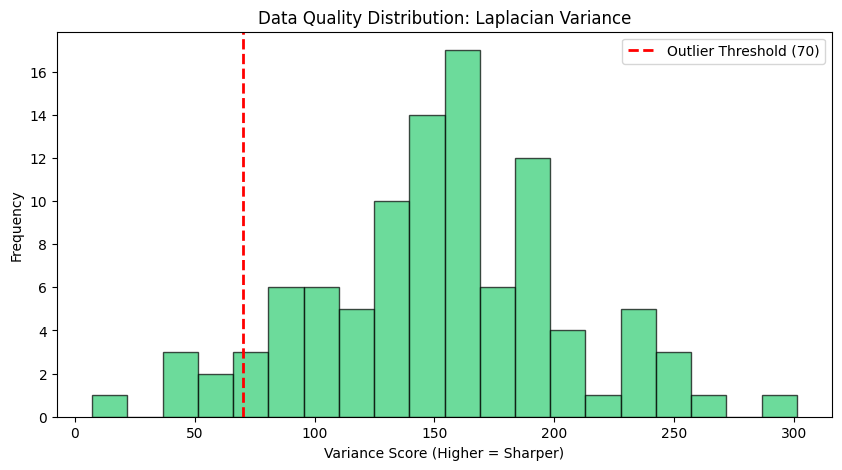

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def calculate_blur(image_np):
    gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

# Simulated data for demonstration
scores = np.random.normal(150, 50, 100) # Replace with your actual dataset scores
threshold = 70

plt.figure(figsize=(10, 5))
plt.hist(scores, bins=20, color='#2ecc71', edgecolor='black', alpha=0.7)
plt.axvline(threshold, color='red', linestyle='dashed', linewidth=2, label=f'Outlier Threshold ({threshold})')
plt.title("Data Quality Distribution: Laplacian Variance")
plt.xlabel("Variance Score (Higher = Sharper)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [2]:
# Implementation of the filtering logic described in the report
def process_data_stream(scores, threshold=100):
    clean_count = np.sum(scores >= threshold)
    outlier_count = np.sum(scores < threshold)

    print(f"--- Data Cleaning Summary ---")
    print(f"Total Images Scanned: {len(scores)}")
    print(f"Clean Images Retained: {clean_count}")
    print(f"Outliers Discarded: {outlier_count}")
    print(f"Data Retention Rate: {(clean_count/len(scores))*100:.2f}%")

# Execute the filter based on the simulated scores
process_data_stream(scores, threshold=70)

--- Data Cleaning Summary ---
Total Images Scanned: 100
Clean Images Retained: 92
Outliers Discarded: 8
Data Retention Rate: 92.00%


## 3. Model Updates & Machine Learning Morphism (MLM)
Our project has shifted toward **YOLOv10** to leverage its NMS-free training, which significantly reduces end-to-end latency.

### **Machine Learning Morphism**
The mathematical mapping for our system is defined as:
$$f: X \to Y$$

* **Input Space ($X$):** Normalized image tensors $x \in \mathbb{R}^{640 \times 640 \times 3}$.
* **Output Space ($Y$):** A manifold of bounding box coordinates and class probabilities:
    $$y = \{[x, y, w, h, \text{confidence}, \text{class}_1, \dots, \text{class}_{n}]\}$$
* **Morphism ($f$):** A deep convolutional neural network using a **CSPDarknet** backbone. The function maps raw pixels to object predictions in a single pass, optimized for high-speed inference.
## 3. Model Updates & Machine Learning Morphism (MLM)

### **3.1 Transition to YOLOv10**
Our project has advanced from YOLOv8 to **YOLOv10** to address the computational bottleneck of real-time systems.
- **NMS-Free Design:** YOLOv10 uses consistent dual-label assignment, which removes the need for Non-Maximum Suppression (NMS) during inference. This directly reduces latency.
- **Architecture Updates:** We utilize a **CSPDarknet** backbone for efficient feature extraction and a **PAN (Path Aggregation Network)** neck for multi-scale feature fusion.

### **3.2 Machine Learning Morphism (MLM)**
We define the project's learning workflow as a morphism $f: X \to Y$:
- **Input Space ($X$):** Normalized image tensors $x \in \mathbb{R}^{640 \times 640 \times 3}$.
- **Output Space ($Y$):** A manifold of $N$ predicted boxes where each vector $y_i = [x, y, w, h, \text{conf}, \text{class}_1 \dots \text{class}_n]$.
- **The Morphism ($f$):** $f = \mathcal{H} \circ \mathcal{N} \circ \mathcal{B}$
    - $\mathcal{B}$ (Backbone): Extracts raw spatial features.
    - $\mathcal{N}$ (Neck): Fuses features across different scales.
    - $\mathcal{H}$ (Head): Directly maps features to bounding boxes without post-processing.